#Método de Punto Fijo


--------------------------------------------------
Iniciando Punto Fijo: Inciso A
--------------------------------------------------
Iteracion 1: Raíz calculada = 1.581139 | Error = 100.000000
Iteracion 2: Raíz calculada = 1.229548 | Error = 0.285951
Iteracion 3: Raíz calculada = 1.426638 | Error = 0.138150
Iteracion 4: Raíz calculada = 1.331951 | Error = 0.071089
Iteracion 5: Raíz calculada = 1.381756 | Error = 0.036045
Iteracion 6: Raíz calculada = 1.356640 | Error = 0.018514
Iteracion 7: Raíz calculada = 1.369593 | Error = 0.009458
Iteracion 8: Raíz calculada = 1.362987 | Error = 0.004847
Iteracion 9: Raíz calculada = 1.366376 | Error = 0.002480
Iteracion 10: Raíz calculada = 1.364643 | Error = 0.001270
Iteracion 11: Raíz calculada = 1.365531 | Error = 0.000650
Iteracion 12: Raíz calculada = 1.365076 | Error = 0.000333
Iteracion 13: Raíz calculada = 1.365309 | Error = 0.000170
Iteracion 14: Raíz calculada = 1.365190 | Error = 0.000087

--> RAÍZ FINAL APROXIMADA PARA Inciso A: 1.365

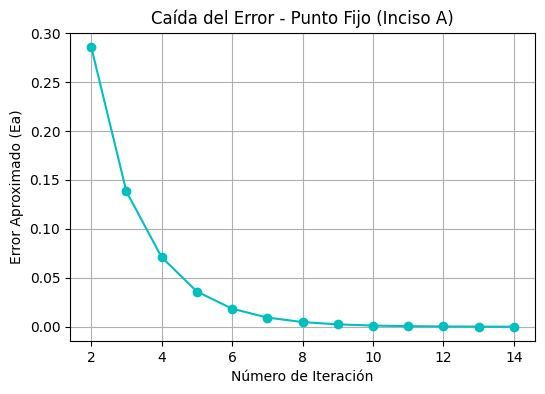


--------------------------------------------------
Iniciando Punto Fijo: Inciso B
--------------------------------------------------
Iteracion 1: Raíz calculada = 0.300000 | Error = 100.000000
Iteracion 2: Raíz calculada = 0.454040 | Error = 0.339265
Iteracion 3: Raíz calculada = 0.463594 | Error = 0.020609
Iteracion 4: Raíz calculada = 0.461795 | Error = 0.003895

--> RAÍZ FINAL APROXIMADA PARA Inciso B: 0.461795


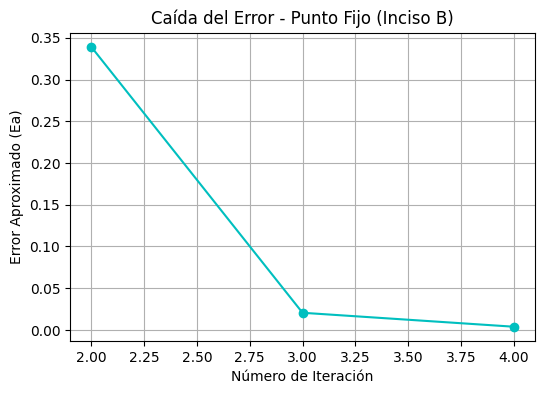


--------------------------------------------------
Iniciando Punto Fijo: Inciso C
--------------------------------------------------
Iteracion 1: Raíz calculada = 2.345208 | Error = 100.000000
Iteracion 2: Raíz calculada = 4.357172 | Error = 0.461759
Iteracion 3: Raíz calculada = 5.527544 | Error = 0.211735
Iteracion 4: Raíz calculada = 6.106011 | Error = 0.094737
Iteracion 5: Raíz calculada = 6.372563 | Error = 0.041828
Iteracion 6: Raíz calculada = 6.491705 | Error = 0.018353

--> RAÍZ FINAL APROXIMADA PARA Inciso C: 6.491705


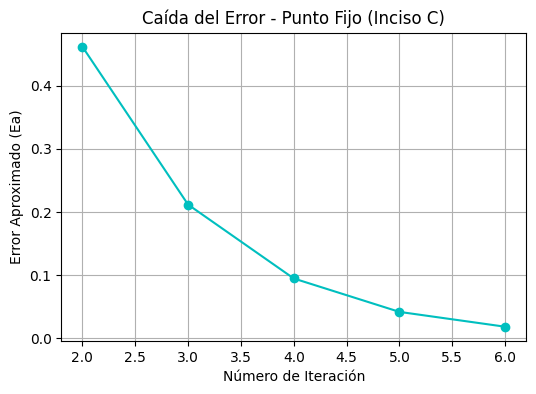


--------------------------------------------------
Iniciando Punto Fijo: Inciso D
--------------------------------------------------
Iteracion 1: Raíz calculada = 0.816497 | Error = 100.000000
Iteracion 2: Raíz calculada = 0.720082 | Error = 0.133893
Iteracion 3: Raíz calculada = 0.759636 | Error = 0.052069
Iteracion 4: Raíz calculada = 0.745434 | Error = 0.019051
Iteracion 5: Raíz calculada = 0.750828 | Error = 0.007183
Iteracion 6: Raíz calculada = 0.748820 | Error = 0.002682
Iteracion 7: Raíz calculada = 0.749573 | Error = 0.001005
Iteracion 8: Raíz calculada = 0.749291 | Error = 0.000376
Iteracion 9: Raíz calculada = 0.749397 | Error = 0.000141
Iteracion 10: Raíz calculada = 0.749358 | Error = 0.000053

--> RAÍZ FINAL APROXIMADA PARA Inciso D: 0.749358


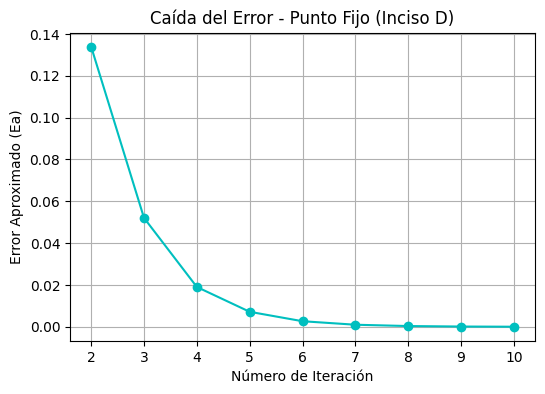

In [9]:
import math
import matplotlib.pyplot as plt

# 1.-Definimos las funciones transformadas g(x) resultantes de despejar x de f(x)=0
# Esto es vital para que Punto Fijo no explote.

# f(x) = x^3 + 4x^2 - 10 = 0  ---> Despejamos la x del término cuadrático
def funcion_g_a(x):
    return math.sqrt((10.0 - (x**3)) / 4.0)

# f(x) = e^(3x) - 4 = 0 ---> Usamos técnica de relajación para forzar iteración iterativa: g(x) = x - 0.1*f(x)
def funcion_g_b(x):
    return x - 0.1 * (math.exp(3*x) - 4.0)

# f(x) = -0.4x^2 + 2.3x + 2.2 = 0 ---> Despejamos la x del término cuadrático
def funcion_g_c(x):
    # Condición de seguridad por si lo de adentro se hace negativo (no pasará con x0=0)
    adentro = (2.3*x + 2.2) / 0.4
    if adentro < 0: return 0
    return math.sqrt(adentro)

# f(x) = x^4 + 3x^2 - 2 = 0 ---> Despejamos la x del término cuadrático
def funcion_g_d(x):
    return math.sqrt((2.0 - (x**4)) / 3.0)


# 2.-Método de Punto Fijo
def ejecutar_punto_fijo(funcion_transformada, X_Inicial, Error_Esperado, Nombre_Inciso):
    print(f"\n--------------------------------------------------")
    print(f"Iniciando Punto Fijo: {Nombre_Inciso}")
    print(f"--------------------------------------------------")

    Error_Actual = 100.0  # El clásico freno forzado
    Punto_Calculado_Pasado = X_Inicial
    Iteracion = 1

    Historial_Iteraciones = []
    Historial_Errores = []

    while Error_Actual > Error_Esperado:
        # La magia de Punto Fijo: evaluar la función g(x) nos da la nueva x
        Punto_Nuevo = funcion_transformada(Punto_Calculado_Pasado)

        # Cálculo de error relativo
        if Iteracion > 1:
            if Punto_Nuevo == 0:
                print("Error: El punto nuevo es 0, no se puede calcular el error relativo.")
                break
            Error_Actual = abs((Punto_Nuevo - Punto_Calculado_Pasado) / Punto_Nuevo)

        # Recolección de datos
        if Iteracion > 1:
            Historial_Iteraciones.append(Iteracion)
            Historial_Errores.append(Error_Actual)

        print(f"Iteracion {Iteracion}: Raíz calculada = {Punto_Nuevo:.6f} | Error = {Error_Actual:.6f}")

        # Preparamos la siguiente vuelta
        Punto_Calculado_Pasado = Punto_Nuevo
        Iteracion = Iteracion + 1

        # Freno de emergencia crítico (Punto Fijo diverge rapidísimo si g(x) está mal despejada)
        if Iteracion > 100:
            print("Alerta: Se superaron las 100 iteraciones. El método diverge.")
            break

    print(f"\n--> RAÍZ FINAL APROXIMADA PARA {Nombre_Inciso}: {Punto_Nuevo:.6f}")

    # ==========================================
    # 3.-Gráficas

    plt.figure(figsize=(6, 4))
    plt.plot(Historial_Iteraciones, Historial_Errores, marker='o', linestyle='-', color='c')
    plt.title(f"Caída del Error - Punto Fijo ({Nombre_Inciso})")
    plt.xlabel("Número de Iteración")
    plt.ylabel("Error Aproximado (Ea)")
    plt.grid(True)
    plt.show()


# 4. Ejecución en secuencia.
# Usamos el punto inicial x0 = 0 dictado por el pizarrón para arrancar.

# Inciso a) Ea = 0.0001
ejecutar_punto_fijo(funcion_g_a, 0.0, 0.0001, "Inciso A")

# Inciso b) Ea = 0.01
ejecutar_punto_fijo(funcion_g_b, 0.0, 0.01, "Inciso B")

# Inciso c) Ea = 3% (0.03 decimal)
ejecutar_punto_fijo(funcion_g_c, 0.0, 0.03, "Inciso C")

# Inciso d) Ea = 0.0001
ejecutar_punto_fijo(funcion_g_d, 0.0, 0.0001, "Inciso D")